# **Promptable Segmentation with MobileSAM**

## **Objectives:**
1. Segment a single, specific object by clicking a point on it — MobileSAM's ONNX encoder/decoder pair, run with `onnxruntime` directly
2. See it correctly isolate one coin even when it's touching its neighbor, with no threshold tuning
3. Contrast this *promptable* approach against notebook 22's *unsupervised* Watershed segmentation, on the exact same `coins.jpg`

> **Assets.** MobileSAM's ONNX export doesn't have a home in `opencv_zoo` (SAM-family models aren't there yet), so this notebook sources the weights from [Acly/MobileSAM](https://huggingface.co/Acly/MobileSAM) on Hugging Face (MIT), `mobile_sam_image_encoder.onnx` and `sam_mask_decoder_single.onnx` → renamed here to `mobilesam_encoder.onnx` (27MB) and `mobilesam_decoder.onnx` (16MB). Traced provenance: the official model is [ChaoningZhang/MobileSAM](https://github.com/ChaoningZhang/MobileSAM) (Apache 2.0), with official weights also mirrored at [dhkim2810/MobileSAM](https://huggingface.co/dhkim2810/MobileSAM) — the Acly export is the same model, just already split into encoder/decoder ONNX graphs, which is exactly the form this notebook needs.
>
> This is the one DNN notebook in the series that reaches for `onnxruntime.InferenceSession` directly instead of `cv2.dnn`. SAM's architecture is a two-part encoder/decoder split with dynamic-shape inputs (variable image size into the encoder, a variable number of point prompts into the decoder) — `cv2.dnn`'s ONNX importer is built around single-graph, fixed-shape models like every other notebook here, and isn't a fit for this one.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **How promptable segmentation works, intuitively**

Every other detector in this series answers one fixed question — "where are the faces / cars / text lines" — decided entirely by training data. SAM answers a different, more general question: "given *this point I'm pointing at*, what's the single object there?" That split is why it's built as two pieces:

- **The encoder** runs once per image and is the expensive part — it turns the whole photo into one dense *embedding* (a `[1, 256, 64, 64]` tensor) that captures everything about the image's content and shape, with no notion yet of what you'll ask for.
- **The decoder** is tiny and runs once per *prompt* — a point (or points, or a box) plus that same embedding go in, and a mask for just the object at that point comes out, in milliseconds. Ask 5 different questions about the same photo and the decoder runs 5 times; the encoder runs once.

That's the trade being made against Watershed below: pay for one expensive whole-image pass up front, then get exact, cheap, on-demand answers about individual objects — versus Watershed's one-shot, no-prompting-needed pass that segments *everything* at once but needs its thresholds tuned to the image.

## **Loading the model and encoding the image**

The encoder expects the image resized so its *longest* side is 1024px (aspect ratio preserved, no crop), RGB, `float32` — it does its own internal mean/std normalization and padding to a full 1024x1024 square, so the raw resized image goes straight in.

In [2]:
import onnxruntime as ort

img = cv2.imread('assets/images/coins.jpg')
h, w = img.shape[:2]
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)

IMG_SIZE = 1024
scale = IMG_SIZE / max(h, w)
resized = cv2.resize(img_rgb, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_LINEAR)

encoder = ort.InferenceSession('assets/models/mobilesam_encoder.onnx')
decoder = ort.InferenceSession('assets/models/mobilesam_decoder.onnx')

# The expensive part — runs exactly once, no matter how many points we click below
image_embedding = encoder.run(None, {'input_image': resized})[0]
print('Image embedding:', image_embedding.shape)

Image embedding: (1, 256, 64, 64)


## **The point-prompt decoder call**

The decoder's ONNX export follows the same contract as Meta's own reference implementation: point coordinates have to be rescaled into the same 1024-space the encoder saw, and — the one genuinely unintuitive part — when there's no box prompt, a **padding point** at `(0, 0)` with label `-1` has to be concatenated onto the real point(s). Skip it and the decoder's attention has nothing telling it "there is no second prompt here," and it produces a meaningless mask covering almost the whole image.

In [3]:
def segment_point(px, py):
    """Click one foreground point (image coordinates) -> boolean mask, IoU estimate."""
    point = np.array([[px, py]], dtype=np.float32)
    label = np.array([1], dtype=np.float32)

    # Mandatory padding point/label when there's no box prompt (see markdown above)
    coords = np.concatenate([point, np.array([[0.0, 0.0]], dtype=np.float32)], axis=0)[None, :, :]
    labels = np.concatenate([label, np.array([-1], dtype=np.float32)], axis=0)[None, :]
    coords = (coords * scale).astype(np.float32)  # into the encoder's 1024-space

    mask_input = np.zeros((1, 1, 256, 256), dtype=np.float32)  # no prior mask to refine
    has_mask_input = np.zeros(1, dtype=np.float32)
    orig_im_size = np.array([h, w], dtype=np.float32)

    masks, iou_predictions, _ = decoder.run(None, {
        'image_embeddings': image_embedding,
        'point_coords': coords,
        'point_labels': labels,
        'mask_input': mask_input,
        'has_mask_input': has_mask_input,
        'orig_im_size': orig_im_size,
    })
    return masks[0, 0] > 0.0, float(iou_predictions[0, 0])  # raw logits: threshold at 0

## **Three clicks, three clean masks**

One point each, on three different coins — including one (green) that's directly touching its neighbor. No thresholds, no morphology, no tuning: just "the object at this pixel."

(112, 210) touching its neighbor       mask covers  1.27% of image, IoU estimate 1.012
(211, 193) top-right region            mask covers  1.52% of image, IoU estimate 1.005
(334,  43) isolated top-right coin     mask covers  2.23% of image, IoU estimate 1.002


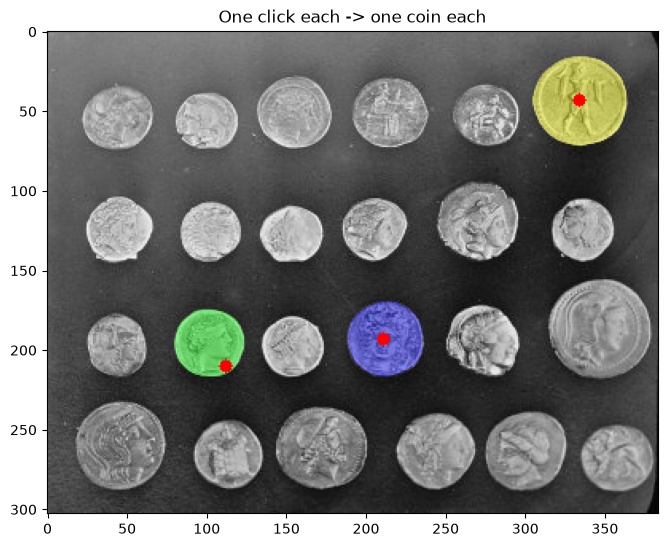

In [4]:
points = [
    ((112, 210), (0, 255, 0), 'touching its neighbor'),
    ((211, 193), (255, 0, 0), 'top-right region'),
    ((334, 43), (0, 255, 255), 'isolated top-right coin'),
]

vis = img.copy()
for (px, py), color, note in points:
    mask, iou = segment_point(px, py)
    print(f'({px:3d}, {py:3d}) {note:26s}  mask covers {mask.mean()*100:5.2f}% of image, IoU estimate {iou:.3f}')
    overlay = vis.copy()
    overlay[mask] = color
    vis = cv2.addWeighted(overlay, 0.4, vis, 0.6, 0)
    cv2.circle(vis, (px, py), 4, (0, 0, 255), -1)

imshow('One click each -> one coin each', vis)

## **Versus Watershed (notebook 22): unsupervised vs. promptable**

Notebook 22 ran Watershed on this exact same `coins.jpg` and drew a boundary through *every* coin in one pass — no clicking required, but it took a whole pipeline (Otsu threshold → morphological opening → distance transform → sure-foreground/background split → `cv2.connectedComponents` for markers) tuned specifically to this image's contrast and coin size. Change the scene and every one of those steps may need re-tuning.

MobileSAM flips the trade completely: zero tuning, one call per object, and it doesn't care whether objects are touching — the green mask above stopped exactly at its neighbor's edge with no distance-transform trick needed. The cost is that it will never hand you "here are all N coins" the way Watershed does — it only ever answers the question you actually asked, one click at a time.

### If you want to push this further

- Add a *negative* point (label `0`) alongside a positive one — click the coin, then click just outside it — and watch the mask tighten to the true boundary instead of bleeding into a busy background.
- The decoder can return 3 mask candidates at once instead of 1 (`multimask_output`-style export) — this notebook's decoder is the single-mask variant; the multi-mask ONNX export from the same source repo returns alternate interpretations (whole coin vs. just its face/portrait) ranked by `iou_predictions`.
- Chain this with notebook 33's YOLOX: run detection first to get box prompts automatically, feed each box into MobileSAM's decoder instead of a hand-clicked point, and get full instance masks with zero manual clicking.